# 01 轴承故障信号仿真

**本节目标**

1. 理解 Randall 冲击响应模型的信号结构：冲击串 → 结构共振响应 → 叠加噪声；
2. 用 `return_components=True` 拆解仿真信号，观察冲击串、干净信号、噪声与合成信号；
3. 对比健康与四类故障（内圈 / 外圈 / 滚动体 / 保持架）信号的时域波形；
4. 观察内圈故障特有的**幅值调制**现象；
5. 计算 SKF 6205 轴承的理论故障特征频率。

**物理模型**（详见 [docs/02 振动信号数学模型与仿真器](../docs/02_signal_model.md)）

轴承局部缺陷每经过一次滚动接触就激发一次结构共振，振动信号建模为

$$x(t) = \sum_k A_k \, h(t - t_k) + n(t), \qquad
h(t) = e^{-2\pi\zeta f_n t}\sin(2\pi f_n t)$$

- $t_k$：第 $k$ 次冲击时刻，名义间隔为故障特征周期，叠加 1% 左右随机抖动模拟滑差；
- $h(t)$：共振频率 $f_n$（默认 4 kHz）、阻尼比 $\zeta$（默认 0.05）的单自由度衰减振荡；
- $A_k$：冲击幅值——内圈故障随转频调制、滚动体故障随保持架频率调制、外圈故障不调制；
- $n(t)$：按目标信噪比加入的高斯白噪声。

特征频率的运动学推导见 [docs/01 轴承故障机理与特征频率](../docs/01_bearing_faults.md)。

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from bearing_fault import Bearing, BearingSimulator, FAULT_TYPES
from bearing_fault.plotting import FAULT_LABELS, plot_waveform

FS = 12000        # 采样频率 (Hz)
RPM = 1797        # 轴转速
DURATION = 3.0    # 信号时长 (s)
SEED = 42         # 固定随机种子，保证结果可复现

## 理论特征频率

四类局部故障的特征频率由轴承几何参数与转频 $f_r$ 决定，例如内圈故障特征频率

$$BPFI = \frac{n}{2} f_r \left(1 + \frac{d}{D}\cos\alpha\right)$$

其中 $n$ 为滚动体个数、$d$ 为滚动体直径、$D$ 为节径、$\alpha$ 为接触角。
`Bearing.characteristic_frequencies` 一次给出全部四个频率。

In [2]:
bearing = Bearing.sk6205()   # CWRU 数据集轴承：n=9, d=7.94 mm, D=39.04 mm, α=0°
fr = RPM / 60.0              # 转频 (Hz)
char_freqs = bearing.characteristic_frequencies(fr)

print(f"转频 fr = {fr:.2f} Hz")
print(f"保持架  FTF  = {char_freqs['cage']:7.2f} Hz")
print(f"滚动体  BSF  = {char_freqs['ball']:7.2f} Hz")
print(f"外圈    BPFO = {char_freqs['outer']:7.2f} Hz")
print(f"内圈    BPFI = {char_freqs['inner']:7.2f} Hz")

转频 fr = 29.95 Hz
保持架  FTF  =   11.93 Hz
滚动体  BSF  =   70.58 Hz
外圈    BPFO =  107.36 Hz
内圈    BPFI =  162.19 Hz


## 信号的解剖：冲击串 → 共振响应 → 加噪

以外圈故障为例，`return_components=True` 返回一个字典，包含合成信号及所有中间分量。
下面四张图（局部放大 0.2 s）自上而下分别是：

1. **冲击串**：每次滚动体经过外圈缺陷产生一次冲击，间隔 ≈ 1/BPFO ≈ 9.3 ms；
2. **干净信号**：冲击串与结构冲击响应 $h(t)$ 的卷积——每次冲击激发一段 4 kHz 衰减振荡；
3. **噪声**：按 SNR = −6 dB 加入的高斯白噪声（噪声功率是信号功率的约 4 倍）；
4. **合成信号**：干净信号 + 噪声，即"传感器实际采集到"的信号。

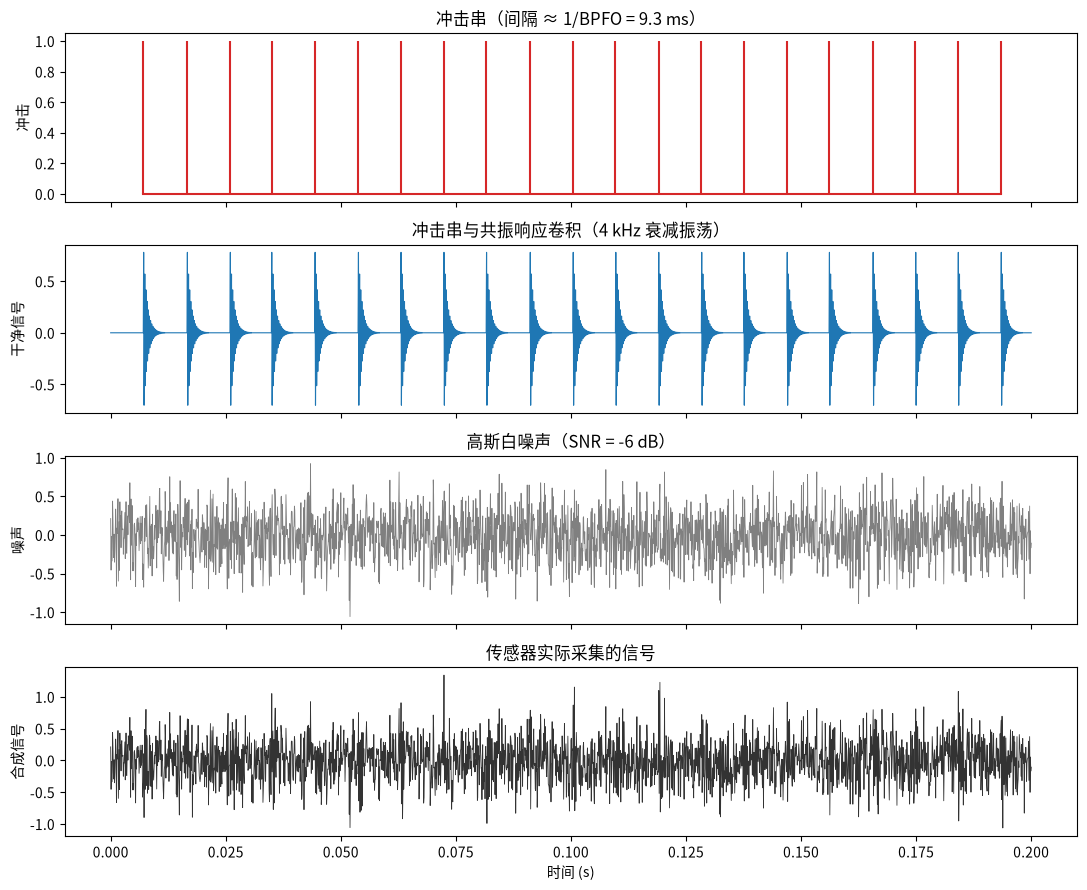

In [3]:
sim = BearingSimulator(fs=FS, duration=DURATION, rpm=RPM, seed=SEED)
comp = sim.signal("outer", snr_db=-6.0, return_components=True)
t = comp["t"]

zoom = (t >= 0) & (t <= 0.2)
fig, axes = plt.subplots(4, 1, figsize=(11, 9), sharex=True)

imp = comp["impact_times"]
imp = imp[imp <= 0.2]
axes[0].stem(imp, np.ones_like(imp), linefmt="tab:red", markerfmt="")
axes[0].set_ylabel("冲击")
axes[0].set_title(f"冲击串（间隔 ≈ 1/BPFO = {1000/char_freqs['outer']:.1f} ms）")

axes[1].plot(t[zoom], comp["clean"][zoom], lw=0.8, color="tab:blue")
axes[1].set_ylabel("干净信号")
axes[1].set_title("冲击串与共振响应卷积（4 kHz 衰减振荡）")

axes[2].plot(t[zoom], comp["noise"][zoom], lw=0.6, color="0.5")
axes[2].set_ylabel("噪声")
axes[2].set_title("高斯白噪声（SNR = -6 dB）")

axes[3].plot(t[zoom], comp["signal"][zoom], lw=0.6, color="0.2")
axes[3].set_ylabel("合成信号")
axes[3].set_title("传感器实际采集的信号")
axes[3].set_xlabel("时间 (s)")
fig.tight_layout()
plt.show()

可以看到：即使故障冲击非常规律（第一张图），混入 −6 dB 噪声后，
合成信号里已经几乎看不出周期性——这正是后续需要包络分析等信号处理手段的原因。

## 五种状态信号对比

健康信号退化为低幅值白噪声；四类故障信号都含有周期性冲击，但冲击间隔不同
（间隔 = 1/特征频率），且幅值调制方式不同。

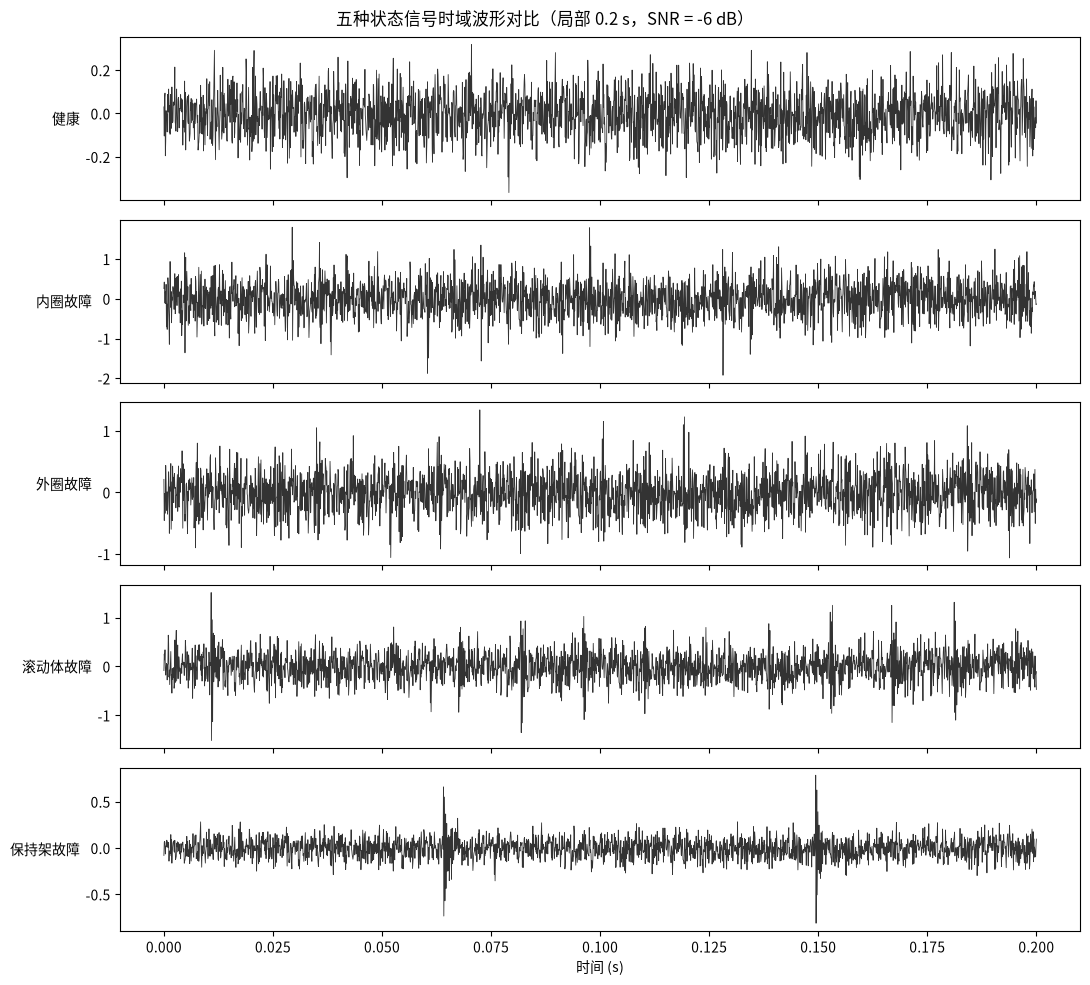

In [4]:
fig, axes = plt.subplots(5, 1, figsize=(11, 10), sharex=True)
for ax, fault in zip(axes, FAULT_TYPES):
    x = BearingSimulator(fs=FS, duration=DURATION, rpm=RPM, seed=SEED).signal(fault)
    mask = (t >= 0) & (t <= 0.2)
    ax.plot(t[mask], x[mask], lw=0.6, color="0.2")
    ax.set_ylabel(FAULT_LABELS[fault], rotation=0, ha="right", va="center")
axes[-1].set_xlabel("时间 (s)")
fig.suptitle("五种状态信号时域波形对比（局部 0.2 s，SNR = -6 dB）")
fig.tight_layout()
plt.show()

单纯从波形上很难区分故障类型——时域统计特征（下一节）和包络谱（第 03 节）
才是区分它们的有效手段。

## 内圈故障的幅值调制

内圈缺陷随轴一起旋转，每转一圈进出载荷区一次，因此冲击幅值被**转频** $f_r$ 调制
（滚动体故障则被保持架频率 FTF 调制，外圈故障位置固定、无调制）。
取不加噪声的干净信号看全长，可以清楚看到幅值以 $1/f_r \approx 33.4$ ms 为周期起伏。

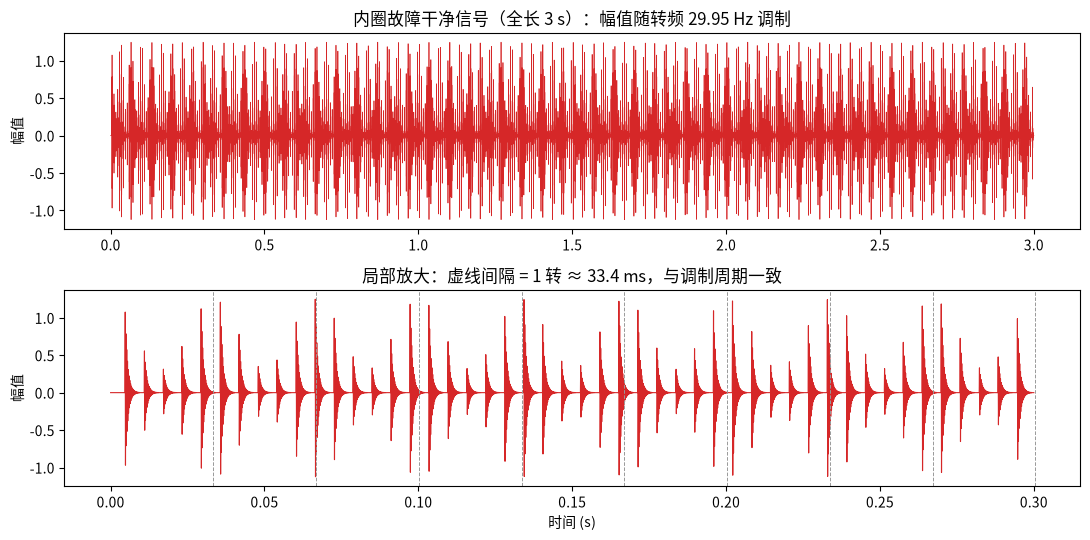

In [5]:
comp_inner = BearingSimulator(fs=FS, duration=DURATION, rpm=RPM, seed=SEED).signal(
    "inner", snr_db=None, return_components=True)
clean_inner = comp_inner["clean"]

fig, axes = plt.subplots(2, 1, figsize=(11, 5.5))
axes[0].plot(t, clean_inner, lw=0.5, color="tab:red")
axes[0].set_title(f"内圈故障干净信号（全长 {DURATION:.0f} s）：幅值随转频 {fr:.2f} Hz 调制")
axes[0].set_ylabel("幅值")

mask = (t >= 0) & (t <= 0.3)
axes[1].plot(t[mask], clean_inner[mask], lw=0.8, color="tab:red")
for k in range(1, 10):
    axes[1].axvline(k / fr, color="0.6", ls="--", lw=0.7)
axes[1].set_title("局部放大：虚线间隔 = 1 转 ≈ 33.4 ms，与调制周期一致")
axes[1].set_xlabel("时间 (s)")
axes[1].set_ylabel("幅值")
fig.tight_layout()
plt.show()

**小结**：仿真器把"缺陷每转产生若干次冲击、冲击激发共振、共振被转频调制"
这一物理过程量化成了可复现的信号。后续各节的分析方法都将在这类信号上展开。

→ 下一节：[02 时域统计特征](02_time_domain_features.ipynb)